## Post-project IRB Likert-scale questions
df1: participant background & level, engagement & authenticity, learning process & self-efficacy, tool/feedback usefulness, cognitive load, team/coordination, group/individual preferences.
- Data Collection: Final Project Chat App (116 participants /130 students)
- Goal: Project learning, encouragement, and tool effectiveness
- Analysis Method: Percentage of each likert option

In [1]:
import pandas as pd

df = pd.read_csv("IRB_EoT_survey_project.csv", header=1)
pd.set_option('display.max_colwidth', None)

In [2]:
# What has changed from last version:
  # remove learning process data and keep tool usefulness
  # Separate by Category
  # Put (n=116) in title
  # Change scale of neutrals portion to match overall sentiment

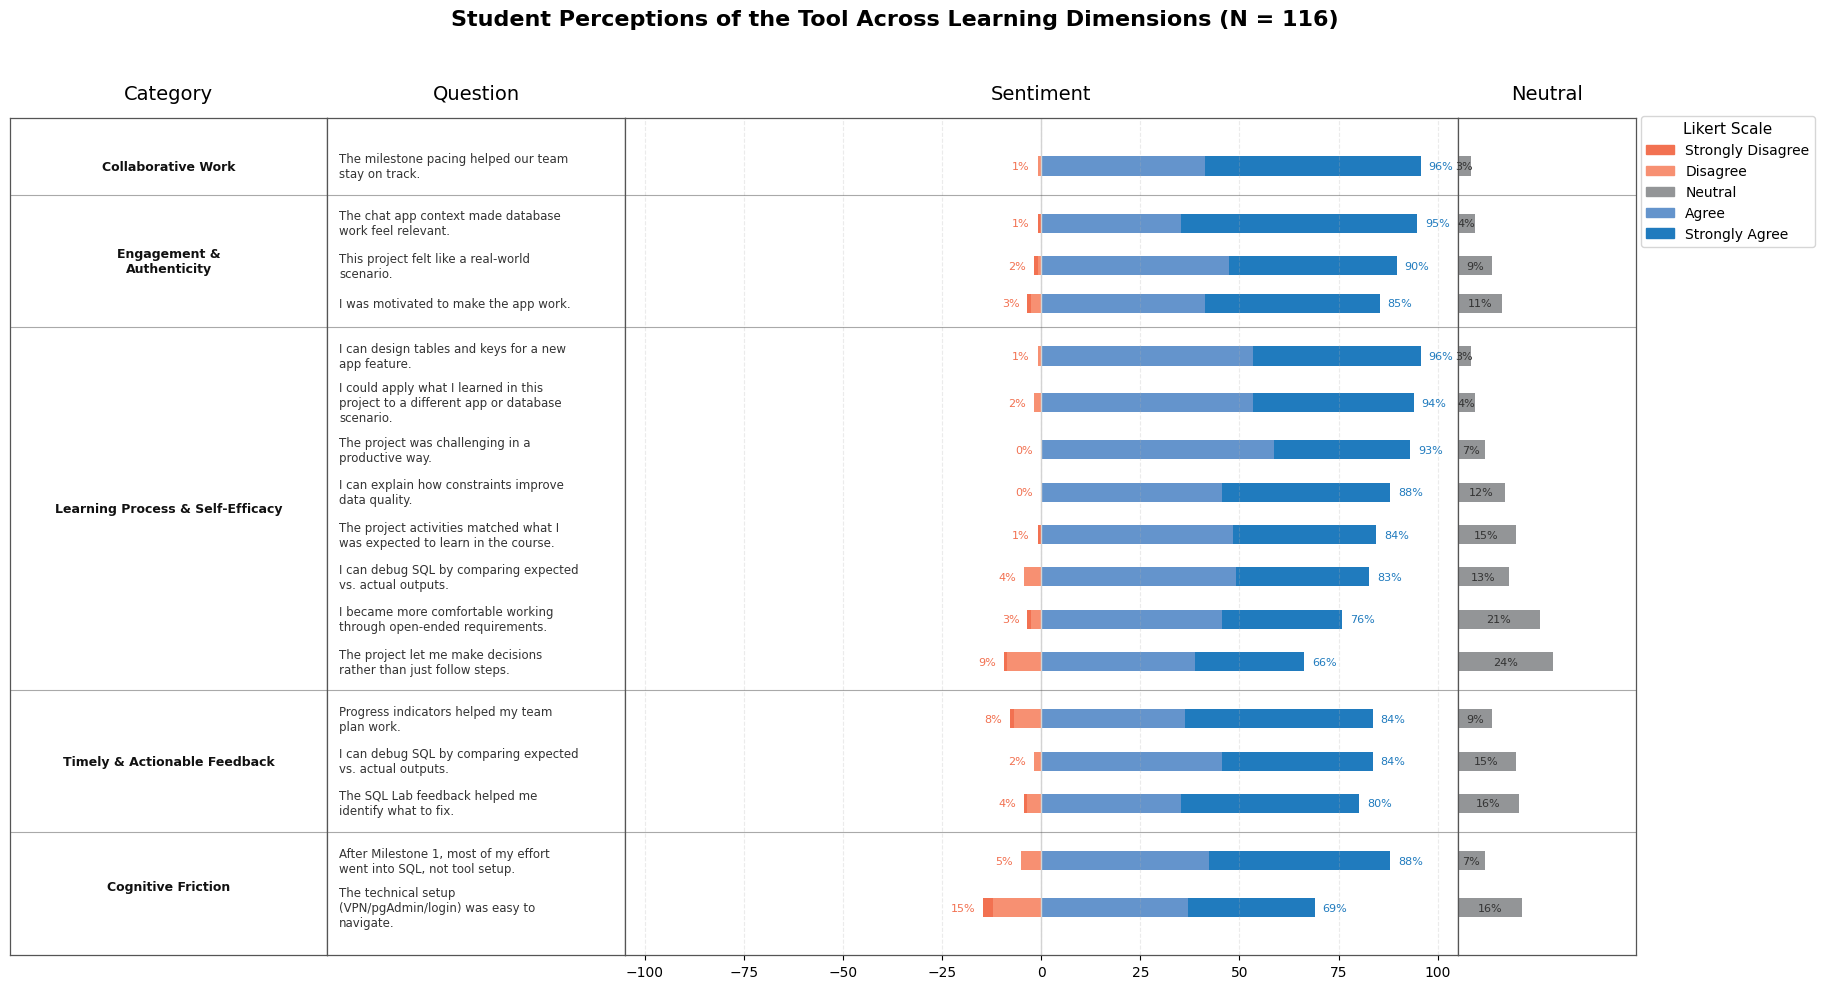

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

LIKERT_ORDER = [
    "Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"
]

COLORS = {
    "Strongly Disagree": "#f27151",
    "Disagree":          "#f79072",
    "Neutral":           "#939597",
    "Agree":             "#6494cc",
    "Strongly Agree":    "#207bbe"
}

FILTERED_QUESTION = (
    "Learning process & self-efficacy "
    "[I can debug SQL by comparing expected vs. actual outputs.]"
)

CATEGORY_LABELS = {
    "Engagement & Authenticity":        "Engagement &\nAuthenticity",
    "Learning Process & Self-Efficacy": "Learning Process\n& Self-Efficacy",
    "Tool/Feedback Usefulness":         "Timely & Actionable Feedback",
    "Cognitive Load / Friction":        "Cognitive Friction",
    "Team/Coordination":                "Collaborative Work",
}

BORDER_COLOR = "#555555"

def split_question(text):
    if "[" in text and "]" in text:
        category = text.split("[")[0].strip()
        question  = text.split("[")[-1].replace("]", "").strip()
    else:
        category, question = "Other", text
    return category, question

def wrap_text(text, width=38):
    return "\n".join(textwrap.wrap(text, width))

questions = [c for c in df.columns if "[" in c and c != FILTERED_QUESTION]
df_likert  = df[questions]

summary_rows = []
for col in df_likert.columns:
    category, question = split_question(col)
    counts = (
        df_likert[col].value_counts(normalize=True)
        .reindex(LIKERT_ORDER).fillna(0) * 100
    )
    summary_rows.append({
        "category":          category.title(),
        "question":          wrap_text(question),
        "Strongly Disagree": counts["Strongly Disagree"],
        "Disagree":          counts["Disagree"],
        "Neutral":           counts["Neutral"],
        "Agree":             counts["Agree"],
        "Strongly Agree":    counts["Strongly Agree"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df["total_pos"] = summary_df["Agree"] + summary_df["Strongly Agree"]
summary_df["total_neg"] = summary_df["Strongly Disagree"] + summary_df["Disagree"]

category_avg_pos = summary_df.groupby("category")["total_pos"].mean()
summary_df["category_avg_pos"] = summary_df["category"].map(category_avg_pos)

summary_df = summary_df.sort_values(
    ["category_avg_pos", "total_pos"], ascending=[False, False]
)

BASE_H     = 1.00
LINE_EXTRA = 0.28
GAP        = 0.45

y_positions     = []
plot_rows       = []
category_ranges = []
current_y       = 0.0

for category in summary_df["category"].unique():
    cat_df  = summary_df[summary_df["category"] == category]
    first_y = None

    for _, row in cat_df.iterrows():
        q_text     = row["question"]
        num_lines  = q_text.count("\n") + 1
        row_height = BASE_H + (num_lines - 1) * LINE_EXTRA

        if first_y is None:
            first_y = current_y

        bar_y = current_y + row_height / 2
        y_positions.append(bar_y)
        plot_rows.append(row)
        current_y += row_height

    end_y = current_y
    category_ranges.append({
        "category": category,
        "mid":      first_y + (end_y - first_y) / 2,
        "divider":  current_y + GAP / 2
    })
    current_y += GAP

plot_df    = pd.DataFrame(plot_rows)
neu_series = plot_df["Neutral"]
total_neg  = plot_df["total_neg"]
total_pos  = plot_df["total_pos"]
y_bars     = y_positions
BAR_HEIGHT = 0.58

fig, (ax_cat, ax_q, ax_main, ax_neu) = plt.subplots(
    ncols=4, sharey=True,
    figsize=(18, 10),
    gridspec_kw={
        "width_ratios": [1.6, 1.5, 4.2, 0.9],
        "wspace": 0.0
    }
)

ax_cat.set_xlim(0, 1)
ax_cat.set_xticks([])
ax_cat.set_yticks([])

for cat in category_ranges:
    label = CATEGORY_LABELS.get(cat["category"], cat["category"])
    ax_cat.text(
        0.5, cat["mid"], label,
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        color="#111111", multialignment="center"
    )

ax_cat.set_title("Category", fontsize=14, pad=14)

ax_q.set_xlim(0, 1)
ax_q.set_xticks([])
ax_q.set_yticks([])

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax_q.text(
        0.04, y_positions[i], row["question"],
        ha="left", va="center",
        fontsize=8.5, color="#333333"
    )

ax_q.set_title("Question", fontsize=14, pad=14)

left = np.zeros(len(y_bars))

for col in ["Disagree", "Strongly Disagree"]:
    vals = -plot_df[col]
    ax_main.barh(y_bars, vals, left=left, color=COLORS[col], height=BAR_HEIGHT)
    left += vals

left = np.zeros(len(y_bars))
for col in ["Agree", "Strongly Agree"]:
    vals = plot_df[col]
    ax_main.barh(y_bars, vals, left=left, color=COLORS[col], height=BAR_HEIGHT)
    left += vals

for i, y in enumerate(y_bars):
    ax_main.text(-total_neg.iloc[i] - 2, y, f"{total_neg.iloc[i]:.0f}%",
                 ha="right", va="center", fontsize=8, color=COLORS["Strongly Disagree"])
    ax_main.text( total_pos.iloc[i] + 2, y, f"{total_pos.iloc[i]:.0f}%",
                 ha="left",  va="center", fontsize=8, color=COLORS["Strongly Agree"])

ax_main.set_xlim(-105, 105)
ax_main.axvline(0, color="lightgray", lw=1)
ax_main.set_title("Sentiment", fontsize=14, pad=14)
ax_main.set_yticks([])
ax_main.grid(axis="x", linestyle="--", alpha=0.25)

ax_neu.barh(y_bars, neu_series, color=COLORS["Neutral"], height=BAR_HEIGHT)

for i, value in enumerate(neu_series):
    ax_neu.text(
        value / 2, y_bars[i], f"{value:.0f}%",
        ha="center", va="center", fontsize=8, color="#333333"
    )

ax_neu.set_xlim(0, 45)
ax_neu.set_title("Neutral", fontsize=14, pad=14)
ax_neu.set_xticks([])
ax_neu.set_yticks([])

for cat in category_ranges[:-1]:
    for ax in [ax_cat, ax_q, ax_main, ax_neu]:
        ax.axhline(cat["divider"], color=BORDER_COLOR, lw=0.8, alpha=0.5)

for ax in [ax_cat, ax_q, ax_main, ax_neu]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.9)
        spine.set_color(BORDER_COLOR)

ax_cat.invert_yaxis()

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[lbl], label=lbl)
    for lbl in LIKERT_ORDER
]
fig.legend(
    handles=legend_handles,
    loc="upper right", bbox_to_anchor=(1.015, 0.885),
    title="Likert Scale", fontsize=10, title_fontsize=11, frameon=True
)

plt.suptitle(
    "Student Perceptions of the Tool Across Learning Dimensions (N = 116)",
    fontsize=16, fontweight="semibold", y=0.985
)

fig.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()